In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

In [2]:
def initialize_parameters(layers_dims):
    parameters = {}
    L = len(layers_dims) - 1

    for l in range(1, L + 1):
        n_prev = layers_dims[l - 1]
        n_curr = layers_dims[l]

        parameters[f"W{l}"] = np.random.randn(n_curr, n_prev) * 0.01
        parameters[f"b{l}"] = np.zeros((n_curr, 1))

    return parameters


def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)


def softmax(Z):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z_shift)
    return expZ / np.sum(expZ, axis=0, keepdims=True)


def forward_propagation(X, parameters):
    cache = {}
    A = X
    L = len(parameters) // 2

    for l in range(1, L):
        Z = np.dot(parameters[f"W{l}"], A) + parameters[f"b{l}"]
        A = relu(Z)
        cache[f"Z{l}"] = Z
        cache[f"A{l}"] = A

    ZL = np.dot(parameters[f"W{L}"], A) + parameters[f"b{L}"]
    AL = softmax(ZL)

    cache[f"Z{L}"] = ZL
    cache[f"A{L}"] = AL

    return AL, cache


def compute_cost(AL, Y):
    m = Y.shape[1]
    cost = -np.sum(Y * np.log(AL + 1e-8)) / m
    return cost


def backward_propagation(X, Y, cache, parameters):
    grads = {}
    L = len(parameters) // 2
    m = Y.shape[1]

    AL = cache[f"A{L}"]
    dZ = AL - Y

    for l in reversed(range(1, L + 1)):
        A_prev = X if l == 1 else cache[f"A{l-1}"]

        dW = (1/m) * np.dot(dZ, A_prev.T)
        db = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        grads[f"dW{l}"] = dW
        grads[f"db{l}"] = db

        if l > 1:
            dA_prev = np.dot(parameters[f"W{l}"].T, dZ)
            dZ = dA_prev * relu_derivative(cache[f"Z{l-1}"])

    return grads


def update_parameters(parameters, grads, learning_rate):
    L = len(parameters) // 2

    for l in range(1, L + 1):
        parameters[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
        parameters[f"b{l}"] -= learning_rate * grads[f"db{l}"]

    return parameters


def model(X, Y, layers_dims, num_iterations=10000, learning_rate=0.1, print_cost=False):
    costs = []
    parameters = initialize_parameters(layers_dims)

    for i in range(num_iterations):
        AL, cache = forward_propagation(X, parameters)
        cost = compute_cost(AL, Y)
        grads = backward_propagation(X, Y, cache, parameters)
        parameters = update_parameters(parameters, grads, learning_rate)

        if i % 100 == 0:
            costs.append(cost)

    return parameters, costs


def predict(X, parameters):
    AL, _ = forward_propagation(X, parameters)
    return np.argmax(AL, axis=0)


In [3]:
X = np.array([[0,0], [0,1], [1,0], [1,1]]).T
Y = np.array([[1,0], [0,1], [0,1], [1,0]]).T



Architecture : [2, 4, 2]
Prédictions : [0 0 1 0]


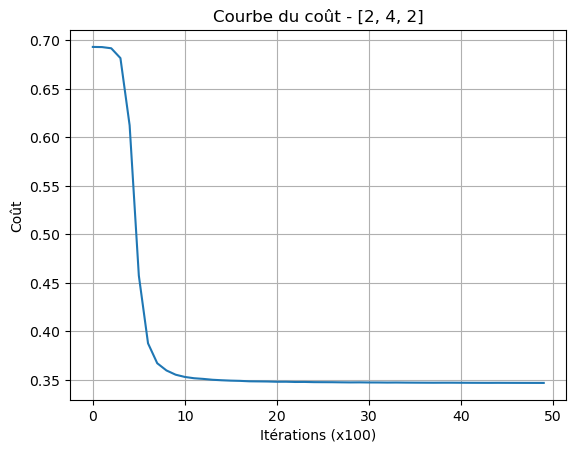


Architecture : [2, 8, 8, 2]
Prédictions : [0 1 1 0]


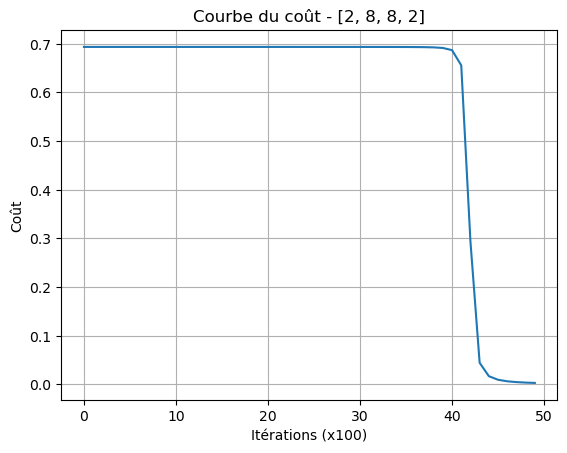


Architecture : [2, 6, 5, 4, 2]
Prédictions : [0 1 1 0]


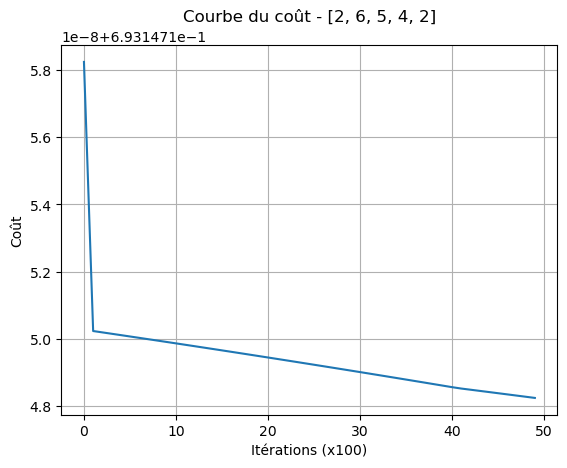

In [4]:
architectures = [
    [2, 4, 2],
    [2, 8, 8, 2],
    [2, 6, 5, 4, 2]
]

for arch in architectures:
    print("\nArchitecture :", arch)
    params, costs = model(X, Y, arch, num_iterations=5000, learning_rate=0.1)
    print("Prédictions :", predict(X, params))

    plt.plot(costs)
    plt.title(f"Courbe du coût - {arch}")
    plt.xlabel("Itérations (x100)")
    plt.ylabel("Coût")
    plt.grid(True)
    plt.show()
